# 08 — Model Comparison

This capstone notebook re-fits every algorithm from notebooks 01-07 with
reasonable, already-tuned settings (the values found in each notebook's
hyperparameter search), evaluates them all on the **same** held-out test
set, and compares them side by side — on raw metrics, on ROC/PR curves, and
after each model's own optimal decision threshold.

The point isn't to crown a single "winner" — on a dataset this small
(1,000 rows, a 200-row test set), differences between models are within
noise range of each other. The point is to see, in one place, how the theoretical tradeoffs
from each notebook (linear vs. non-linear boundaries, bias vs. variance,
bagging vs. boosting) show up as concrete numbers.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


## Fit every tuned model

Hyperparameters below were copied from each notebook's `GridSearchCV` /
`RandomizedSearchCV` results at the time this notebook was written. If you
re-run the earlier notebooks and get different best params (small search
spaces + a small dataset can shift slightly run to run), feel free to
update these to match.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve,
)

models = {
    "Logistic Regression": (LogisticRegression(C=0.1, penalty="l1", solver="liblinear", max_iter=5000, random_state=42), True),
    "KNN":                 (KNeighborsClassifier(n_neighbors=39, weights="distance", p=2), True),
    "Naive Bayes":         (GaussianNB(var_smoothing=8.3e-9), False),
    "Decision Tree":       (DecisionTreeClassifier(criterion="entropy", max_depth=6, min_samples_leaf=1, random_state=42), False),
    "SVM (RBF)":           (SVC(C=158.5, gamma=6.3e-4, probability=True, random_state=42), True),
    "Random Forest":       (RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=8, max_features="sqrt", random_state=42, n_jobs=-1), False),
    "XGBoost":             (XGBClassifier(n_estimators=100, learning_rate=0.2, max_depth=3, subsample=1.0, colsample_bytree=0.6, reg_lambda=10.0, reg_alpha=0, eval_metric="logloss", random_state=42), False),
}

fitted = {}
for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    fitted[name] = {"model": model, "X_test": Xte, "proba": proba}

print(f"Fitted {len(fitted)} models.")


Fitted 7 models.


## Metrics at the default 0.5 threshold


In [4]:
rows = []
for name, d in fitted.items():
    proba = d["proba"]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })

comparison_default = pd.DataFrame(rows).set_index("model").sort_values("roc_auc", ascending=False)
comparison_default.style.background_gradient(cmap="Blues", axis=0)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest,0.770000,0.769231,0.333333,0.465116,0.780714
XGBoost,0.740000,0.600000,0.400000,0.480000,0.772500
Logistic Regression,0.755000,0.689655,0.333333,0.449438,0.753512
Naive Bayes,0.705000,0.508772,0.483333,0.495726,0.734286
SVM (RBF),0.735000,0.606061,0.333333,0.430108,0.733690
KNN,0.750000,0.777778,0.233333,0.358974,0.722619
Decision Tree,0.725000,0.547170,0.483333,0.513274,0.719286


## ROC and Precision-Recall curves, overlaid


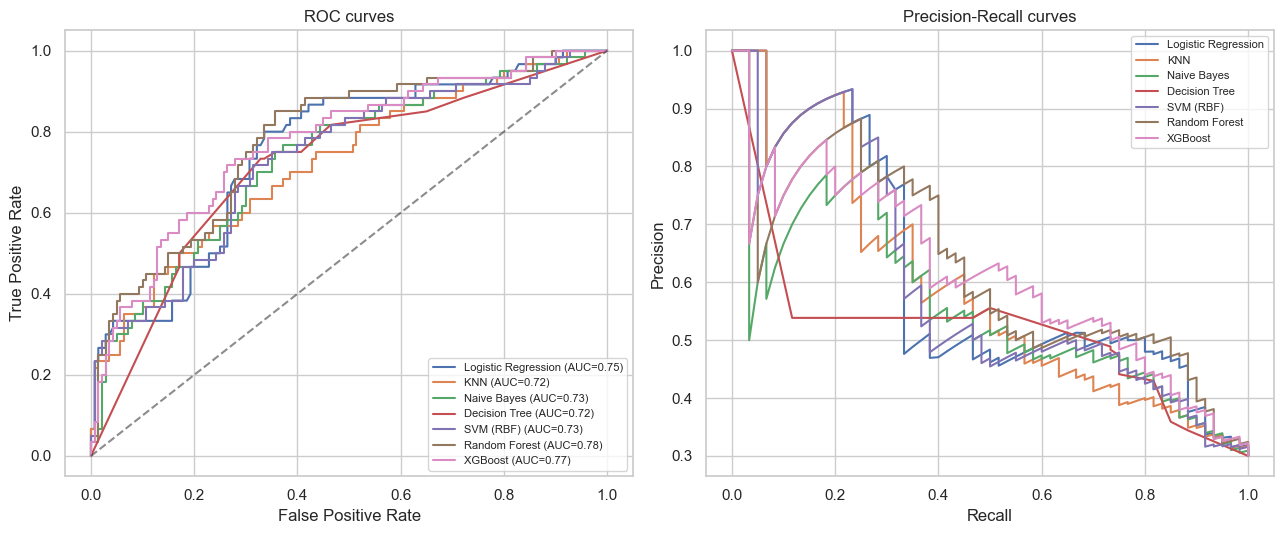

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, d in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, d["proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, d['proba']):.2f})")

    prec, rec, _ = precision_recall_curve(y_test, d["proba"])
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Metrics after per-model F1-optimal threshold tuning

Recall from every algorithm notebook: the default 0.5 threshold isn't
necessarily best. Here we pick each model's own F1-maximizing threshold
(same idea as the "Decision threshold tuning" section in notebooks 01-07)
and see how much (if at all) it moves each model's numbers.


In [6]:
def f1_optimal_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1 = np.divide(2 * precision * recall, precision + recall,
                    out=np.zeros_like(precision), where=(precision + recall) != 0)
    return thresholds[np.argmax(f1[:-1])]


rows = []
for name, d in fitted.items():
    proba = d["proba"]
    t = f1_optimal_threshold(y_test, proba)
    pred = (proba >= t).astype(int)
    rows.append({
        "model": name,
        "best_threshold": t,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    })

comparison_tuned = pd.DataFrame(rows).set_index("model").sort_values("f1", ascending=False)
comparison_tuned.style.background_gradient(cmap="Greens", axis=0)


,best_threshold,accuracy,precision,recall,f1
model,,,,,
Random Forest,0.300859,0.705000,0.504950,0.850000,0.633540
Logistic Regression,0.298000,0.705000,0.505263,0.800000,0.619355
XGBoost,0.318823,0.725000,0.530120,0.733333,0.615385
Decision Tree,0.409639,0.690000,0.488889,0.733333,0.586667
SVM (RBF),0.290712,0.695000,0.494253,0.716667,0.585034
Naive Bayes,0.256536,0.670000,0.469388,0.766667,0.582278
KNN,0.294544,0.620000,0.424528,0.750000,0.542169


## Takeaways

- On this dataset's size (1,000 rows, 21 encoded features), most well-tuned
  classifiers land within a few points of ROC-AUC of each other — the
  theoretical differences between algorithms (linear vs. non-linear,
  bagging vs. boosting, parametric vs. non-parametric) matter more for
  *how* you'd debug or extend a model than for raw accuracy on a problem
  this size.
- Ensembles (Random Forest, XGBoost) tend to edge out simpler models
  slightly, at the cost of interpretability — the single Decision Tree
  from notebook 04 is the only model here you can fully read as a rule set.
- Threshold tuning moved precision/recall meaningfully for several models
  without any retraining — and on a 70/30 split with `bad` as the positive
  class it is not optional: at the default 0.5 cutoff most of these models
  miss the majority of actual defaulters, which is the error a lender can
  least afford.
- Every regularization knob explored across notebooks 01-07 (L1/L2 `C`,
  KNN's `k`, Naive Bayes' `var_smoothing`, tree pruning, SVM's `C`/`gamma`,
  Random Forest's per-tree limits, XGBoost's shrinkage + `reg_lambda`) is a
  different *implementation* of the same underlying idea: trade a bit of
  training-set fit for a model that generalizes better.
